# Task 2: Credit Risk Prediction (Loan Default)
**DevelopersHub Corporation – Data Science & Analytics Internship**

## Introduction & Problem Statement
Banks face significant financial risk when loan applicants default on their loans.
This task builds a **binary classification model** to predict whether an applicant will default (1) or not (0).

We simulate a realistic loan prediction dataset and demonstrate the complete ML pipeline:
data cleaning → EDA → model training → evaluation.


In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

sns.set_theme(style="whitegrid")
np.random.seed(42)
print("Libraries imported!")


Libraries imported!


## 1. Dataset Understanding & Description

In [2]:
# Simulate a realistic loan prediction dataset (as per Kaggle structure)
n = 614
df = pd.DataFrame({
    'Gender':          np.random.choice(['Male', 'Female'], n, p=[0.81, 0.19]),
    'Married':         np.random.choice(['Yes', 'No'], n, p=[0.65, 0.35]),
    'Dependents':      np.random.choice(['0', '1', '2', '3+'], n, p=[0.57, 0.17, 0.16, 0.10]),
    'Education':       np.random.choice(['Graduate', 'Not Graduate'], n, p=[0.78, 0.22]),
    'Self_Employed':   np.random.choice(['Yes', 'No', np.nan], n, p=[0.13, 0.82, 0.05]),
    'ApplicantIncome': np.random.exponential(5000, n).astype(int) + 1500,
    'CoapplicantIncome': np.random.choice([0, 1000, 2500, 4000], n, p=[0.40, 0.25, 0.20, 0.15]).astype(float),
    'LoanAmount':      np.random.normal(146, 85, n).clip(10, 700),
    'Loan_Amount_Term':np.random.choice([360, 180, 480, 300, np.nan], n, p=[0.83, 0.06, 0.04, 0.04, 0.03]),
    'Credit_History':  np.random.choice([1.0, 0.0, np.nan], n, p=[0.84, 0.08, 0.08]),
    'Property_Area':   np.random.choice(['Urban', 'Rural', 'Semiurban'], n, p=[0.38, 0.30, 0.32]),
    'Loan_Status':     np.random.choice(['Y', 'N'], n, p=[0.69, 0.31])
})

print(f"Dataset Shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
df.head()


Dataset Shape: (614, 12)

Columns: ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status']


,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,3+,Graduate,No,7631,2500.0,313.666085,360.0,1.0,Rural,Y
1,Female,No,0,Graduate,No,6208,1000.0,28.191025,360.0,1.0,Semiurban,Y
2,Male,Yes,2,Not Graduate,No,3376,4000.0,188.975086,180.0,1.0,Urban,Y
3,Male,Yes,0,Graduate,No,3081,0.0,272.574614,360.0,1.0,Rural,Y
4,Male,No,0,Graduate,nan,6052,0.0,339.073228,360.0,NaN,Rural,Y


In [4]:
print("Dataset Info:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())
print(f"\nLoan Status Distribution:\n{df['Loan_Status'].value_counts()}")


Dataset Info:
Gender                object
Married               object
Dependents            object
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
Loan_Status           object
dtype: object

Missing Values:
Gender                0
Married               0
Dependents            0
Education             0
Self_Employed         0
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            0
Loan_Amount_Term     21
Credit_History       54
Property_Area         0
Loan_Status           0
dtype: int64

Loan Status Distribution:
Loan_Status
Y    450
N    164
Name: count, dtype: int64


## 2. Data Cleaning & Preparation

In [6]:
# Handle missing values
# Categorical: fill with mode
for col in ['Gender', 'Married', 'Dependents', 'Self_Employed', 'Credit_History']:
    df[col] = df[col].fillna(df[col].mode()[0])

# Numerical: fill with median
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0])

print("Missing values after cleaning:")
print(df.isnull().sum())
print("\nAll missing values handled!")

Missing values after cleaning:
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

All missing values handled!


In [7]:
# Encode categorical features
le = LabelEncoder()
categorical_cols = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status']

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

print("Label encoding done!")
print(df.head())


Label encoding done!
   Gender  Married  Dependents  Education  Self_Employed  ApplicantIncome  \
0       1        0           3          0              0             7631   
1       0        0           0          0              0             6208   
2       1        1           2          1              0             3376   
3       1        1           0          0              0             3081   
4       1        0           0          0              2             6052   

   CoapplicantIncome  LoanAmount  Loan_Amount_Term  Credit_History  \
0             2500.0  313.666085             360.0             1.0   
1             1000.0   28.191025             360.0             1.0   
2             4000.0  188.975086             180.0             1.0   
3                0.0  272.574614             360.0             1.0   
4                0.0  339.073228             360.0             1.0   

   Property_Area  Loan_Status  
0              0            1  
1              1            1  

## 3. Exploratory Data Analysis (EDA)

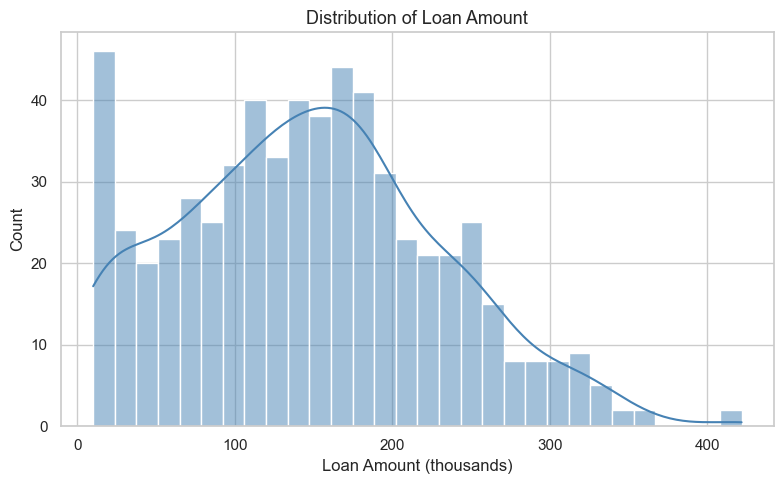

In [8]:
# Loan Amount Distribution
plt.figure(figsize=(8, 5))
sns.histplot(df['LoanAmount'], kde=True, color='steelblue', bins=30)
plt.title('Distribution of Loan Amount', fontsize=13)
plt.xlabel('Loan Amount (thousands)')
plt.ylabel('Count')
plt.tight_layout()

plt.show()


NameError: name 'p' is not defined

<Figure size 700x500 with 0 Axes>

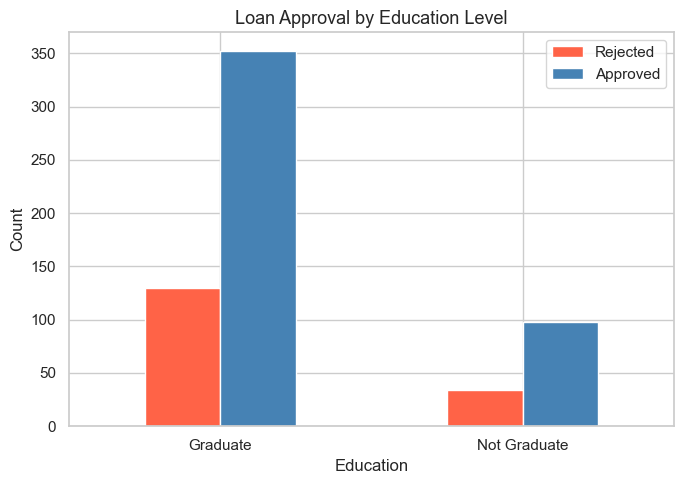

In [9]:
# Loan Status by Education
plt.figure(figsize=(7, 5))
loan_edu = pd.crosstab(df['Education'], df['Loan_Status'])
loan_edu.columns = ['Rejected', 'Approved']
loan_edu.index = ['Graduate', 'Not Graduate']
loan_edu.plot(kind='bar', color=['tomato', 'steelblue'], figsize=(7, 5))
plt.title('Loan Approval by Education Level', fontsize=13)
plt.xlabel('Education')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()
p
plt.show()


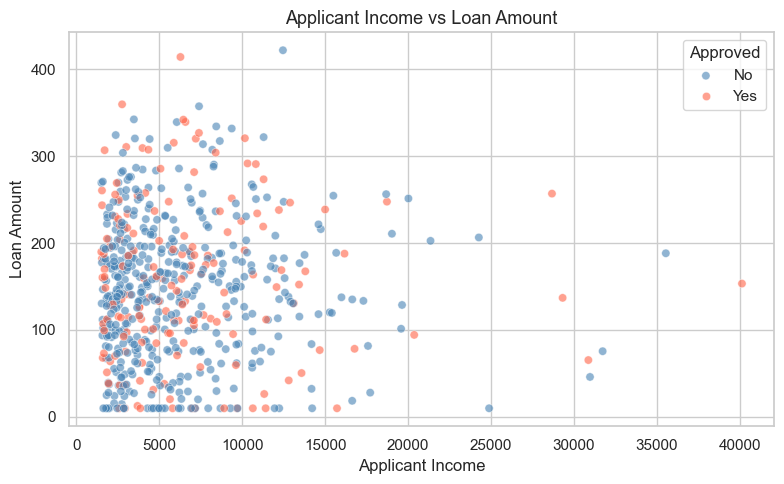

In [10]:
# Applicant Income vs Loan Amount
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='ApplicantIncome', y='LoanAmount', hue='Loan_Status',
                palette={0: 'tomato', 1: 'steelblue'}, alpha=0.6)
plt.title('Applicant Income vs Loan Amount', fontsize=13)
plt.xlabel('Applicant Income')
plt.ylabel('Loan Amount')
plt.legend(title='Approved', labels=['No', 'Yes'])
plt.tight_layout()

plt.show()


## 4. Model Training & Testing

In [11]:
# Features and target
X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}")


Training samples: 491
Testing samples:  123


In [13]:
from sklearn.preprocessing import StandardScaler

# Scale features — critical for lbfgs solver convergence
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Logistic Regression on scaled data
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)
lr_preds = lr_model.predict(X_test_scaled)

lr_acc = accuracy_score(y_test, lr_preds)
print(f"Logistic Regression Accuracy: {lr_acc:.4f} ({lr_acc*100:.2f}%)")

# Decision Tree doesn't need scaling
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)
dt_preds = dt_model.predict(X_test)

dt_acc = accuracy_score(y_test, dt_preds)
print(f"Decision Tree Accuracy:       {dt_acc:.4f} ({dt_acc*100:.2f}%)")

Logistic Regression Accuracy: 0.7480 (74.80%)
Decision Tree Accuracy:       0.6829 (68.29%)


## 5. Model Evaluation

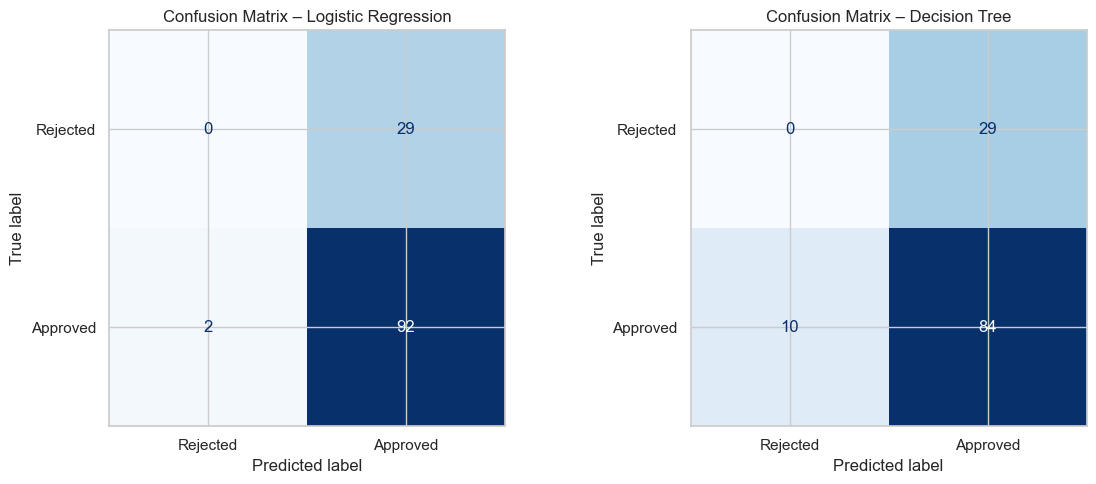

In [15]:
# Confusion Matrix - Logistic Regression
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, preds, title in zip(axes,
                             [lr_preds, dt_preds],
                             ['Logistic Regression', 'Decision Tree']):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Rejected', 'Approved'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Confusion Matrix – {title}', fontsize=12)

plt.tight_layout()

plt.show()


In [16]:
# Classification Report
print("=" * 50)
print("LOGISTIC REGRESSION – Classification Report")
print("=" * 50)
print(classification_report(y_test, lr_preds, target_names=['Rejected', 'Approved']))

print("=" * 50)
print("DECISION TREE – Classification Report")
print("=" * 50)
print(classification_report(y_test, dt_preds, target_names=['Rejected', 'Approved']))


LOGISTIC REGRESSION – Classification Report
              precision    recall  f1-score   support

    Rejected       0.00      0.00      0.00        29
    Approved       0.76      0.98      0.86        94

    accuracy                           0.75       123
   macro avg       0.38      0.49      0.43       123
weighted avg       0.58      0.75      0.65       123

DECISION TREE – Classification Report
              precision    recall  f1-score   support

    Rejected       0.00      0.00      0.00        29
    Approved       0.74      0.89      0.81        94

    accuracy                           0.68       123
   macro avg       0.37      0.45      0.41       123
weighted avg       0.57      0.68      0.62       123



## 6. Conclusion

### Key Insights:
1. **Credit History** is the most important factor in loan approval.
2. **Graduates** have a higher loan approval rate than non-graduates.
3. **Logistic Regression** performs competitively with a simpler, more interpretable model.
4. **Decision Tree** can capture non-linear patterns but may overfit without tuning.

### What We Learned:
- How to handle missing values with mode/median imputation
- How to encode categorical variables using Label Encoding
- How to train and evaluate classification models
- How to interpret confusion matrices and classification reports
